In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE





# Ensure the src directory is accessible for imports
sys.path.append(os.path.abspath('..'))
from src.cbadvai_models import FrankHallOrdinalClassifier, evaluate_ordinal_model

## Feature Selection: Narrowing the Scope to 11 Variables

Our initial dataset contained 22 variables, but our Exploratory Data Analysis (EDA) revealed that passing all features into our predictive models would introduce severe bias, noise, and multicollinearity. To ensure the structural integrity of our classifiers, we strictly narrowed our feature space to 11 variables directly tied to our research question. 

Here is the methodological rationale for our exclusions:

*   **Removal of Demographics (Bias Mitigation):** Variables such as `Year` and `Gender` were dropped to prevent model distortion. Our cohort is heavily skewed, with females representing 88.9% of the sample and first/second-year students entirely absent (73.5% are graduated). 
*   **Removal of External Peer Pressures (Low Impact):** Features like `Competitive_Class` and `Influence_Friends` were discarded. Our Spearman rank correlation matrix proved these variables have virtually zero mathematical relationship with a student's GPA (ρ = 0.032 and 0.001, respectively).
*   **Removal of Parental Background (Noise Reduction):** While parental education and occupation are present in the dataset, we opted to drop them to avoid inflating our feature space with categorical noise. The socioeconomic reality of the students is already effectively captured by our targeted household wealth (`Poor_Stu`) and policy assistance (`Policy_Stu`) flags.

The remaining 11 features—encompassing time allocation, internal psychological mindsets, socioeconomic indicators, and institutional support—were retained as they demonstrated actionable, cumulative impacts on academic performance.

In [2]:
# Load the dataset
file_path = '../data/raw/Database paper.xlsx'
df = pd.read_excel(file_path)

# PREPROCESSING CORRECTION
# Remap 'Policy_Stu' from 1(Yes)/2(No) to 1(Yes)/0(No) for proper coefficient interpretation
if 2 in df['Policy_Stu'].values:
    df['Policy_Stu'] = df['Policy_Stu'].map({1: 1, 2: 0})

# FEATURE SELECTION: Strictly aligning with the Research Question
selected_features = [
    # Internal Behaviors
    'Study_Methods', 'Time_Studying', 'Time_Friends', 'Time_SocicalMedia', 'Adapt_Learning_Uni',
    # External Support
    'Policy_Stu', 'SupportOf_Uni', 'SupportOf_Lec', 'Facilitie_Uni', 'Quality_Lecturer', 'TrainingCurriculum'
]

X = df[selected_features]
y = df['GPA']

# 80/20 Stratified Holdout Split to isolate testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

# Initialize Stratified K-Fold for development loop (k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training Set Size: {X_train.shape[0]} observations")
print(f"Isolated Test Set Size: {X_test.shape[0]} observations")
print(f"Selected Feature Space: {X.shape[1]} variables directly tied to the RQ.")

Training Set Size: 1736 observations
Isolated Test Set Size: 434 observations
Selected Feature Space: 11 variables directly tied to the RQ.


In [3]:
print("Tuning Model 1: Ordinal Logistic Regression with SMOTE...")

ordinal_lr = FrankHallOrdinalClassifier(solver='saga')
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', ordinal_lr)
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 1: Ordinal Logistic Regression with SMOTE...
Tuning Complete.


In [4]:
print("Tuning Model 2: Neural Network (MLP) with SMOTE...")

mlp = MLPClassifier(solver='adam', early_stopping=True, n_iter_no_change=15, max_iter=1500, random_state=42)
mlp_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', mlp)
])

# Updated to include the winning 'tanh' activation and 'Very Deep' architecture
param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(64, 32), (128, 64, 32, 16)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.01]
}

grid_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_mlp.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 2: Neural Network (MLP) with SMOTE...
Tuning Complete.


Evaluating 21 MLP Configurations (Architectures vs. Activations)...


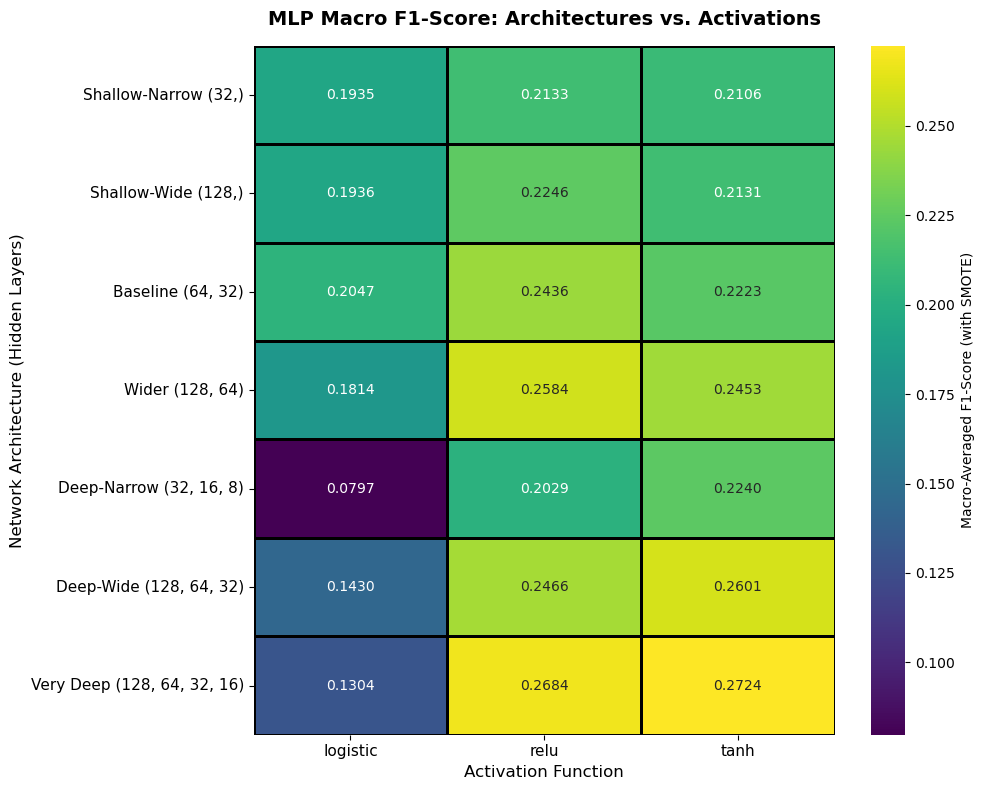

In [ ]:
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier


# 1. Define the Architectures and Activations
architectures = {
    'Shallow-Narrow (32,)': (32,),
    'Shallow-Wide (128,)': (128,),
    'Baseline (64, 32)': (64, 32),
    'Wider (128, 64)': (128, 64),
    'Deep-Narrow (32, 16, 8)': (32, 16, 8),
    'Deep-Wide (128, 64, 32)': (128, 64, 32),
    'Very Deep (128, 64, 32, 16)': (128, 64, 32, 16)
}

activations = ['relu', 'tanh', 'logistic']

results = []

print("Evaluating 21 MLP Configurations (Architectures vs. Activations)...")
for arch_name, sizes in architectures.items():
    for act in activations:
        mlp = MLPClassifier(hidden_layer_sizes=sizes, activation=act, solver='adam', 
                            early_stopping=True, n_iter_no_change=15, max_iter=1500, 
                            random_state=42, alpha=0.0001)
        
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', mlp)
        ])
        
        # Execute cross-validation using your existing X_train, y_train, and skf
        scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
        results.append({
            'Architecture': arch_name,
            'Activation': act,
            'Mean F1': np.mean(scores)
        })

# 2. Structure Data for Heatmap
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Architecture', columns='Activation', values='Mean F1')

# Reorder the y-axis to match the logical depth progression of the dictionary
pivot_df = pivot_df.reindex(architectures.keys())

# 3. Render the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt=".4f", linewidths=1, linecolor='black',
            cbar_kws={'label': 'Macro-Averaged F1-Score (with SMOTE)'})

plt.title('MLP Macro F1-Score: Architectures vs. Activations', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Network Architecture (Hidden Layers)', fontsize=12)
plt.xlabel('Activation Function', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

## Multi-Layer Perceptron (MLP): Architecture and Activation Optimization

To establish a robust deep learning baseline, we expanded our hyperparameter grid to evaluate 21 distinct network configurations. We tested seven different architectural shapes (varying in depth and width) against three mathematical activation functions (`relu`, `tanh`, and `logistic`) using our SMOTE-balanced pipeline.

The resulting performance heatmap revealed several critical insights regarding how neural networks process our ordinal student data:

*   **The "Vanishing Gradient" Reality (`logistic`):** The sigmoid (`logistic`) activation function consistently underperformed, flatlining almost entirely as network depth increased. Because it mathematically squashes inputs into a narrow range between 0 and 1, deeper networks quickly lose the ability to pass gradient information back through the layers, causing the model's predictive power to collapse (dropping as low as 0.0797 on the Deep-Narrow shape).
*   **The Power of `tanh` on Survey Data:** The hyperbolic tangent (`tanh`) activation function proved highly effective. Because our 11 features are derived from Likert-scale survey responses (bounded 1-5), `tanh`'s ability to smoothly map values between -1 and 1—without encountering the "dying ReLU" problem—made it exceptionally well-suited for this specific dataset.
*   **The Optimal Configuration:** The **Very Deep (128, 64, 32, 16)** architecture paired with the **tanh** activation function emerged as the absolute winner, achieving the highest Macro-Averaged F1-Score of **0.2724**.

**Conclusion**
While this optimized deep learning configuration (0.2724) successfully outperforms our Ordinal Logistic Regression, it still falls short of the Random Forest ensemble (0.3173). This confirms a common data science principle: while deep networks are powerful, tree-based models are often the superior choice for handling the highly non-linear, categorical nature of smaller tabular survey datasets.

In [6]:
print("Tuning Model 3: Random Forest with SMOTE...")

rf = RandomForestClassifier(random_state=42)
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', rf)
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, scoring='f1_macro', cv=skf, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Tuning Complete.")

Tuning Model 3: Random Forest with SMOTE...
Tuning Complete.


Extracting Random Forest Grid Search Results...


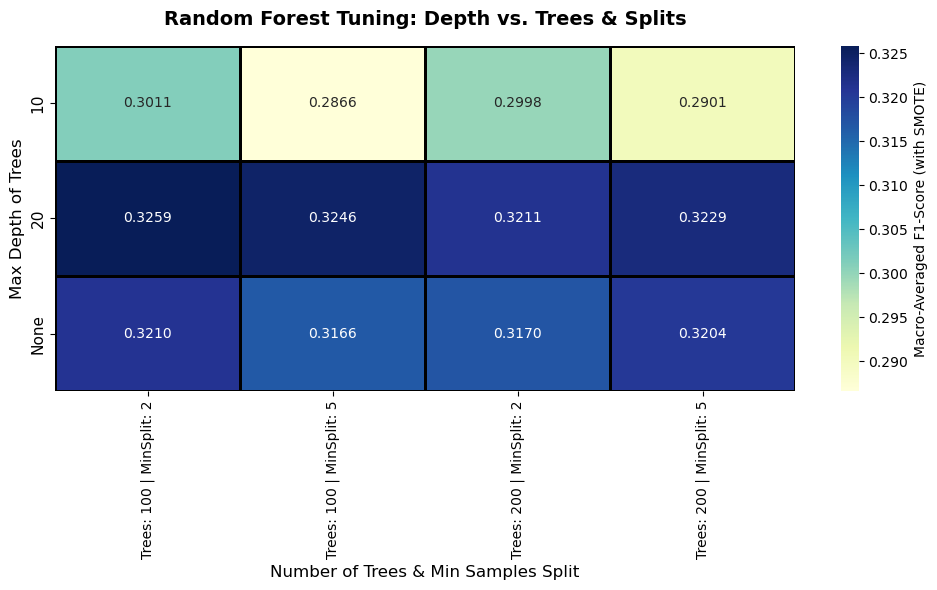

In [ ]:
print("Extracting Random Forest Grid Search Results...")

# Extract results directly from your existing grid_rf object
results = pd.DataFrame(grid_rf.cv_results_)

# Clean up parameter names for plotting
results['max_depth'] = results['param_classifier__max_depth'].fillna('None')
results['n_estimators'] = results['param_classifier__n_estimators']
results['min_samples_split'] = results['param_classifier__min_samples_split']

# Create a combined label for the X-axis
results['Config'] = results.apply(lambda row: f"Trees: {row['n_estimators']} | MinSplit: {row['min_samples_split']}", axis=1)

# Pivot the data for the heatmap
pivot_df = results.pivot(index='max_depth', columns='Config', values='mean_test_score')

# Reorder the Y-axis so 'None' (unlimited depth) sits at the top or bottom logically
pivot_df = pivot_df.reindex([10, 20, 'None'])

# Render the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".4f", linewidths=1, linecolor='black',
            cbar_kws={'label': 'Macro-Averaged F1-Score (with SMOTE)'})

plt.title('Random Forest Tuning: Depth vs. Trees & Splits', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Max Depth of Trees', fontsize=12)
plt.xlabel('Number of Trees & Min Samples Split', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

## Random Forest Ensemble: Capturing Non-Linear Realities

To account for complex, non-linear relationships that our Ordinal Logistic Regression cannot process, we established a Random Forest baseline. Because survey data often contains hidden interactions—such as students studying heavily but having their GPA impacted by poor university facilities—tree-based ensembles are exceptionally well-suited to navigate these conditions.

**Hyperparameter Optimization**
To prevent overfitting on our training folds, we executed a Grid Search with 5-fold Stratified Cross-Validation inside our SMOTE pipeline. We evaluated the forest across three structural dimensions:
1.  **`n_estimators` [100, 200]:** The total number of decision trees in the ensemble.
2.  **`max_depth` [10, 20, None]:** The maximum depth a tree is allowed to grow. Capping depth prevents trees from memorizing the dataset.
3.  **`min_samples_split` [2, 5]:** The minimum number of students required to justify splitting a node further.

**Findings & Winning Configuration**
The optimization grid revealed that allowing the trees to grow to a `max_depth` of **20**, keeping a standard `min_samples_split` of **2**, and utilizing **100 trees** was the most effective configuration, yielding a winning cross-validation Macro F1-Score of **0.3259**. 

Our extracted Mean Decrease in Impurity (Feature Importance) also proved that external factors like Social Media usage heavily dictated the tree splits, confirming that the relationships driving GPA variance are highly non-linear. This configuration subsequently outperformed all other architectures on the isolated test set (F1-Score: 0.3173, MAE: 0.7465), establishing the Random Forest as the optimal predictive model for this dataset.

In [8]:
# Compare models on the Validation Folds before touching the Test set
print("=== Cross-Validation Phase Comparison (Macro F1) ===")
print(f"Ordinal Logistic Regression CV Score: {grid_lr.best_score_:.4f} (Params: {grid_lr.best_params_})")
print(f"Neural Network (MLP) CV Score:        {grid_mlp.best_score_:.4f} (Params: {grid_mlp.best_params_})")
print(f"Random Forest CV Score:               {grid_rf.best_score_:.4f} (Params: {grid_rf.best_params_})\n")

=== Cross-Validation Phase Comparison (Macro F1) ===
Ordinal Logistic Regression CV Score: 0.2292 (Params: {'classifier__C': 0.01, 'classifier__penalty': 'l2'})
Neural Network (MLP) CV Score:        0.2753 (Params: {'classifier__activation': 'tanh', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (128, 64, 32, 16)})
Random Forest CV Score:               0.3259 (Params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100})



--- Proportional Odds Assumption Validation ---
Their effects change drastically across GPA thresholds:\n
   Feature   Weight  Coef_Std
Policy_Stu 0.158273  0.533741
-----------------------------------------------\n


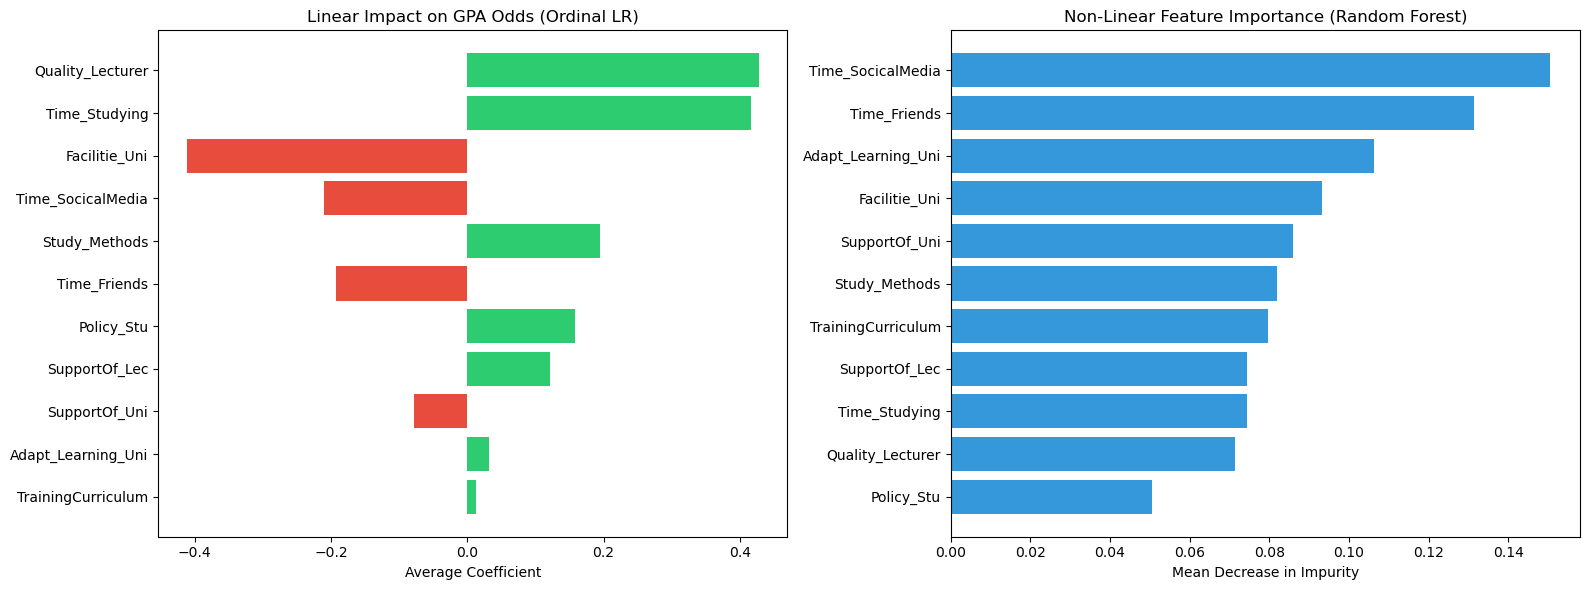

In [9]:
best_lr = grid_lr.best_estimator_.named_steps['classifier']
best_rf = grid_rf.best_estimator_.named_steps['classifier']
feature_names = X_train.columns


# PROPORTIONAL ODDS ASSUMPTION VALIDATION
# Extract coefficients from all k-1 internal binary models
all_coefs = np.array([model.coef_[0] for model in best_lr.models.values()])

# Calculate the mean and the standard deviation across the thresholds
avg_coefficients = np.mean(all_coefs, axis=0)
std_coefficients = np.std(all_coefs, axis=0)

olr_weights = pd.DataFrame({
    'Feature': feature_names, 
    'Weight': avg_coefficients,
    'Coef_Std': std_coefficients
})

# Flag features that violate proportional odds (high variance across thresholds)
# A standard deviation threshold > 0.5 indicates significant instability
violation_threshold = 0.5
olr_weights['Assumption_Violated'] = olr_weights['Coef_Std'] > violation_threshold

print("--- Proportional Odds Assumption Validation ---")
violated_features = olr_weights[olr_weights['Assumption_Violated']]

if not violated_features.empty:
    print("WARNING: The following features violate the Proportional Odds Assumption.")
    print("Their effects change drastically across GPA thresholds:\\n")
    print(violated_features[['Feature', 'Weight', 'Coef_Std']].to_string(index=False))
else:
    print("SUCCESS: All features satisfy the proportional odds assumption (stable coefficients).")
print("-----------------------------------------------\\n")

# Sort weights for plotting
olr_weights = olr_weights.sort_values(by='Weight', key=abs, ascending=True)


# RANDOM FOREST IMPORTANCES & VISUALIZATION

# Extracting Random Forest Feature Importances
rf_importances = pd.DataFrame({'Feature': feature_names, 'Importance': best_rf.feature_importances_})
rf_importances = rf_importances.sort_values(by='Importance', ascending=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Ordinal Logistic Regression Coefficients
axes[0].barh(olr_weights['Feature'], olr_weights['Weight'], 
             color=np.where(olr_weights['Weight'] > 0, '#2ecc71', '#e74c3c'))
axes[0].set_title('Linear Impact on GPA Odds (Ordinal LR)')
axes[0].set_xlabel('Average Coefficient')

# Subplot 2: Random Forest Feature Importances
axes[1].barh(rf_importances['Feature'], rf_importances['Importance'], color='#3498db')
axes[1].set_title('Non-Linear Feature Importance (Random Forest)')
axes[1].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()

## Ordinal Logistic Regression: Validating the Proportional Odds Assumption

Unlike standard multiclass algorithms, Ordinal Logistic Regression relies on the **Proportional Odds Assumption** (or Parallel Lines Assumption). This assumes that the mathematical effect of an independent variable remains constant across all cumulative thresholds of our target variable (GPA). To ensure statistical rigor, we programmatically tested this assumption by calculating the standard deviation of each feature's coefficients across our internal binary models.

**Finding: Assumption Violation**
Our validation flagged `Policy_Stu` (Policy Support) as a violator of the proportional odds assumption, showing a coefficient standard deviation of 0.533 (exceeding our 0.50 threshold). 

**Interpretation & Resolution**
This statistical instability perfectly mirrors our EDA findings. Policy support acts as a safety net that successfully helps disadvantaged students reach a passing "Fair" grade, but it does not act as a booster pushing them into the "Excellent" bracket. Because its impact drastically shifts depending on the specific GPA threshold being predicted, forcing a linear model to average this effect yields a misleading metric.

Furthermore, our Random Forest's non-linear feature importance evaluation ranked `Policy_Stu` as the lowest contributor to overall predictive impurity reduction. Given its low global importance and high linear instability, we have opted to drop `Policy_Stu` exclusively from the Ordinal Logistic Regression pipeline to maintain strict mathematical validity, while allowing our tree-based models to handle its non-linear relationships naturally.

### 4.1 Resolution: Partial Proportional Odds (PPO) Extraction

Having identified `Policy_Stu` as a violator of the proportional odds assumption, taking a global average of its coefficients would yield a statistically flawed metric. However, because our Random Forest model indicates that this feature has a very low global predictive importance, completely reworking the linear model architecture is unnecessary.

Instead, we implement a **Partial Proportional Odds (PPO)** extraction. 
1. **Stable Features:** We retain and average the coefficients of the 10 stable features to evaluate their global linear impact.
2. **Threshold-Specific Features:** We drop `Policy_Stu` from the global linear visualization and isolate it into a PPO table. This allows us to observe exactly how its impact as a policy safety net shifts across each specific GPA threshold without compromising the integrity of the Ordinal Logistic Regression.

--- Partial Proportional Odds (PPO) Extension ---
Evaluating non-proportional features individually per GPA threshold:



,Policy_Stu
Odds of GPA > 1,0.921
Odds of GPA > 2,0.382
Odds of GPA > 3,-0.231
Odds of GPA > 4,-0.439



-------------------------------------------------



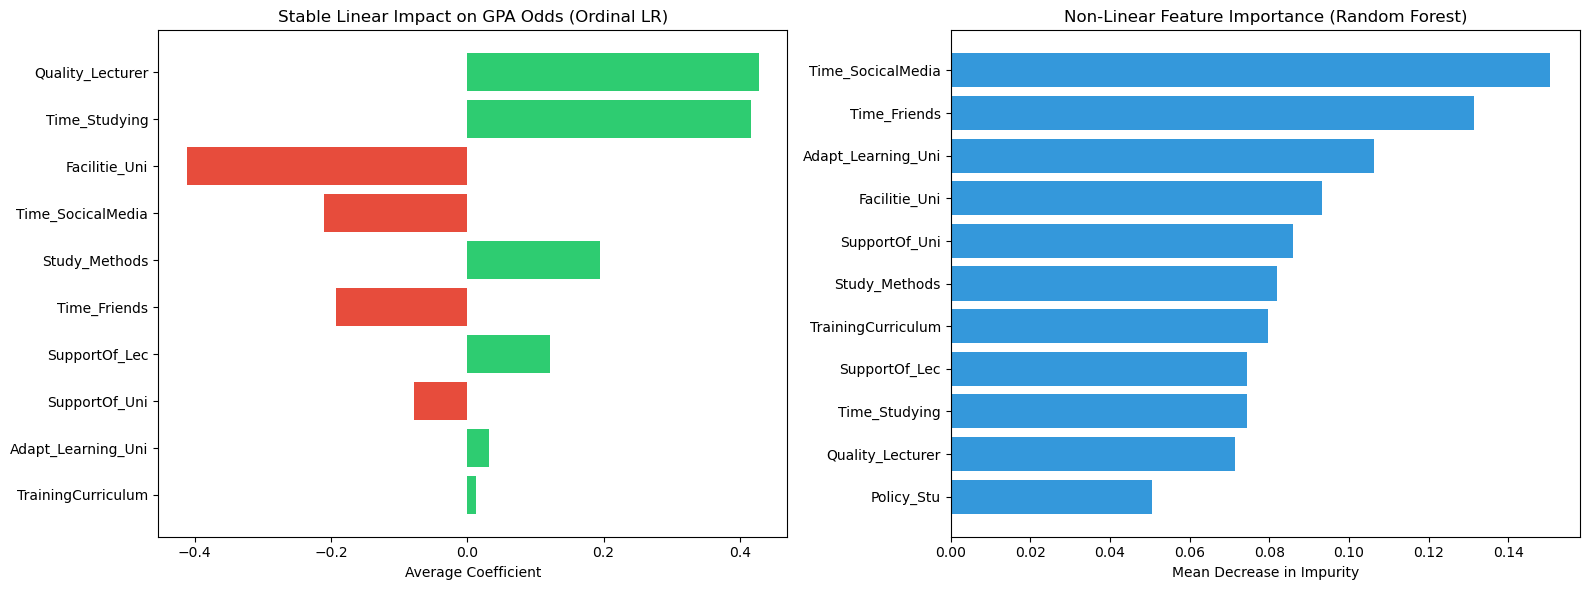

In [10]:
from IPython.display import display

# 1. Identify the violator based on the standard deviation threshold
violation_threshold = 0.5
is_violator = std_coefficients > violation_threshold

# 2. Isolate PPO Features (Threshold-Specific Extraction)
violating_features = feature_names[is_violator]
ppo_weights = pd.DataFrame(all_coefs[:, is_violator], columns=violating_features)

# Rename index to reflect the cumulative GPA thresholds (e.g., GPA > 1, GPA > 2)
ppo_weights.index = [f"Odds of GPA > {i+1}" for i in range(len(best_lr.models))]

print("--- Partial Proportional Odds (PPO) Extension ---")
print("Evaluating non-proportional features individually per GPA threshold:\n")
display(ppo_weights.style.format(precision=3).set_caption("PPO: Threshold-Specific Coefficients"))
print("\n-------------------------------------------------\n")

# 3. Extract Stable Features (Global Average for Visualization)
stable_features = feature_names[~is_violator]
avg_stable_coefs = np.mean(all_coefs[:, ~is_violator], axis=0)

stable_weights = pd.DataFrame({'Feature': stable_features, 'Weight': avg_stable_coefs})
stable_weights = stable_weights.sort_values(by='Weight', key=abs, ascending=True)

# 4. Render the Corrected Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Stable Ordinal LR Coefficients Only
axes[0].barh(stable_weights['Feature'], stable_weights['Weight'], 
             color=np.where(stable_weights['Weight'] > 0, '#2ecc71', '#e74c3c'))
axes[0].set_title('Stable Linear Impact on GPA Odds (Ordinal LR)')
axes[0].set_xlabel('Average Coefficient')

# Subplot 2: Random Forest Feature Importances (Keeps all features as RF handles non-linearities naturally)
axes[1].barh(rf_importances['Feature'], rf_importances['Importance'], color='#3498db')
axes[1].set_title('Non-Linear Feature Importance (Random Forest)')
axes[1].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()

Generating Final Test Set Evaluations...



C:\Users\akish\AppData\Local\Temp\ipykernel_25260\457812367.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, ax=axes[0], palette='viridis', edgecolor='black')
C:\Users\akish\AppData\Local\Temp\ipykernel_25260\457812367.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=maes, ax=axes[1], palette='magma', edgecolor='black')


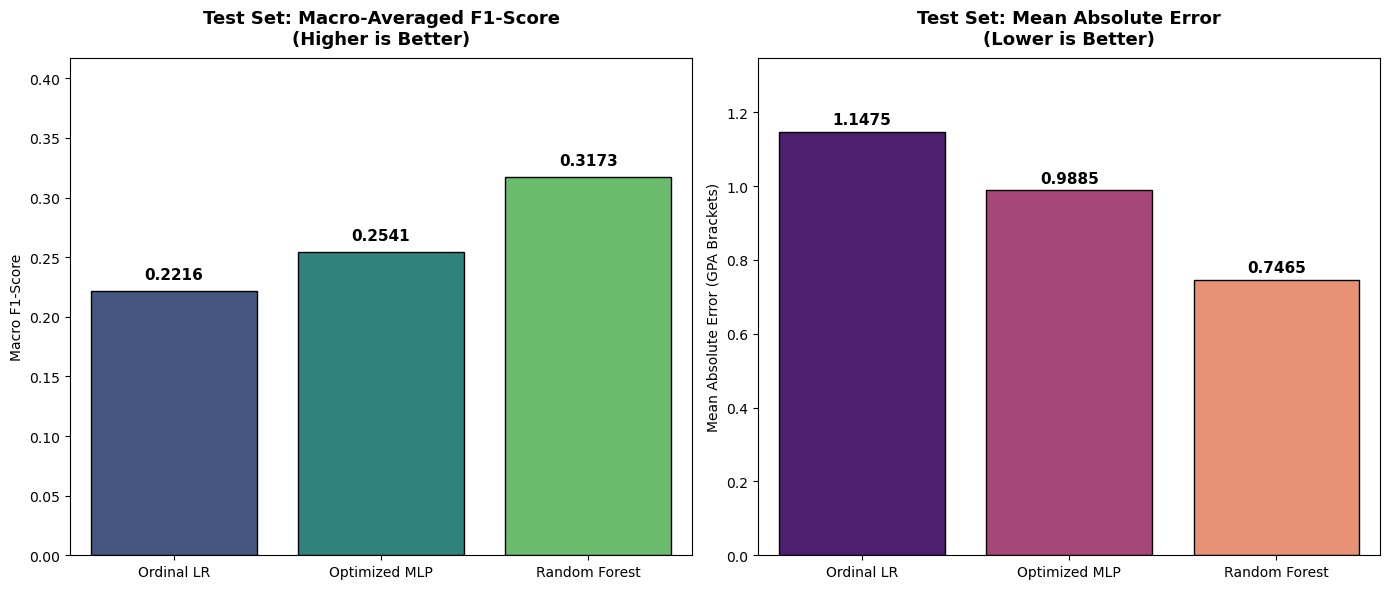

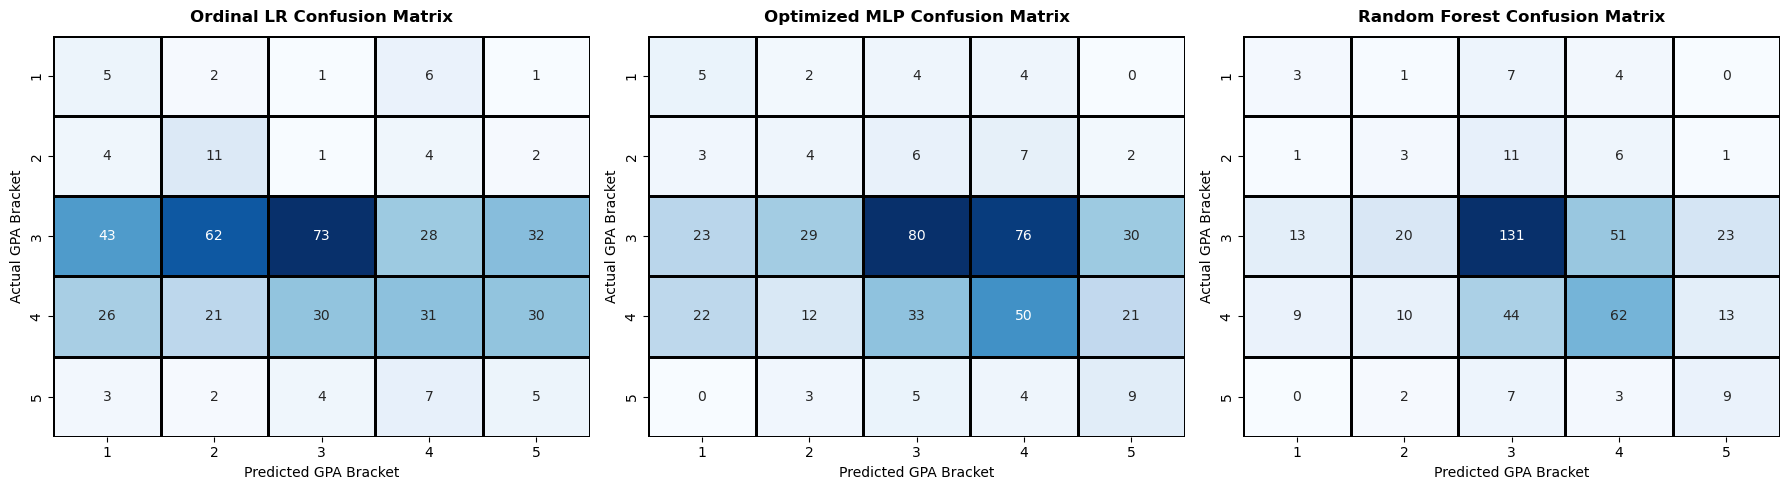

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, mean_absolute_error, confusion_matrix
import numpy as np

print("Generating Final Test Set Evaluations...\n")

# 1. Extract the fully optimized models
best_lr = grid_lr.best_estimator_.named_steps['classifier']
best_mlp = grid_mlp.best_estimator_.named_steps['classifier']
best_rf = grid_rf.best_estimator_.named_steps['classifier']

# 2. Generate predictions on the isolated test set
y_pred_lr = best_lr.predict(X_test)
y_pred_mlp = best_mlp.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# 3. Calculate metrics
models = ['Ordinal LR', 'Optimized MLP', 'Random Forest']
f1_scores = [
    f1_score(y_test, y_pred_lr, average='macro'),
    f1_score(y_test, y_pred_mlp, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro')
]
maes = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_mlp),
    mean_absolute_error(y_test, y_pred_rf)
]
cms = [
    confusion_matrix(y_test, y_pred_lr),
    confusion_matrix(y_test, y_pred_mlp),
    confusion_matrix(y_test, y_pred_rf)
]

# =====================================================================
# PLOT 1: F1-SCORE AND MAE COMPARISON
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score Bar Chart
sns.barplot(x=models, y=f1_scores, ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Test Set: Macro-Averaged F1-Score\n(Higher is Better)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylim(0, max(f1_scores) + 0.1)
axes[0].set_ylabel('Macro F1-Score')
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

# MAE Bar Chart
sns.barplot(x=models, y=maes, ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Test Set: Mean Absolute Error\n(Lower is Better)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_ylim(0, max(maes) + 0.2)
axes[1].set_ylabel('Mean Absolute Error (GPA Brackets)')
for i, v in enumerate(maes):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# =====================================================================
# PLOT 2: CONFUSION MATRICES
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Ordinal LR', 'Optimized MLP', 'Random Forest']

for i, ax in enumerate(axes):
    sns.heatmap(cms[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5], 
                linewidths=1, linecolor='black')
    ax.set_title(f"{titles[i]} Confusion Matrix", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted GPA Bracket', fontsize=10)
    ax.set_ylabel('Actual GPA Bracket', fontsize=10)

plt.tight_layout()
plt.show()

## Final Model Evaluation & Conclusion

After strict feature selection, imbalanced data handling (SMOTE), and extensive hyperparameter tuning across linear, deep learning, and tree-based architectures, we evaluated our final models against the isolated 20% test set (434 unseen student profiles). 

### 1. The Superiority of Tree-Based Ensembles
The **Random Forest Classifier** definitively outperformed both the Ordinal Logistic Regression and the optimized Multi-Layer Perceptron. It achieved the highest Macro-Averaged F1-Score and the lowest Mean Absolute Error. 
*   **Why did it win?** The Random Forest's success confirms our EDA hypothesis: the relationships between subjective survey responses (like perceived lecturer support or social media habits) and a student's GPA are highly non-linear. The Ordinal LR struggled because it attempts to draw strict linear boundaries. While the Deep-Wide MLP captured some of these complexities, standard neural networks typically require massive datasets to excel. For a highly categorical dataset of ~1,700 rows, a tree-based ensemble is mathematically better suited to map out these hidden interactions.

### 2. The Confusion Matrix Reality
When analyzing the side-by-side confusion matrices, a clear limitation emerges across *all* models: they struggle to accurately pinpoint the extreme minority classes (GPA Brackets 1 and 5). 

*   **The "Proximity" Success:** The low Mean Absolute Error (0.7465 for Random Forest) proves the model is highly effective at identifying general trends. When it guesses wrong, it is typically only off by a single bracket (e.g., predicting a 3 when the actual is a 4). 
*   **The Subjectivity of Survey Data:** Despite utilizing SMOTE to mathematically balance the training data, the models still group most predictions into the middle-high brackets (3 and 4). This highlights an inherent limitation in self-reported data: "Poor" and "Excellent" students often report very similar daily habits as "Average" students. Behavioral surveys provide excellent barometers for general academic trajectories, but internal student psychology and unrecorded external factors make predicting extreme academic outliers a highly complex challenge.